# 4-Lobe Lightbridge Fuel

## Burnable Absorber Displacer

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad
from igakit import nurbs
from ttnte.cad.conics import qtrlobe

from ttnte.xs.benchmarks import kaist
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, eig

tn.set_default_dtype(tn.float64)

/home/joebogdn/anaconda3/envs/tt_nte/lib/python3.12/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/joebogdn/anaconda3/envs/tt_nte/lib/python3.12/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/joebogdn/anaconda3/envs/tt_nte/lib/python3.12/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


In [ ]:
# Discretization
num_ordinates = 1024

# Get XS data
xs_server = kaist()

In [3]:
D = 1.26 # Fuel width
D2 = D*0.5
X = 1.36 # Channel pitch
delta = 0.306 # Width of lobes
y2 = delta * 0.5
d = 0.04 # Thickness of cladding at valleys
dmax = 0.102 # Thickness of cladding at ends of the lobes
R = 0.297 # Radius defining outer curve of valleys
a = 0.156 # Displacer width

y1 = y2-d # Half of width of inner lobe
x1 = (D2 - R - y2 - dmax) # Portrusion of innerlobe
x2 = x1 + dmax # Portrusion of outer lobe

In [4]:
# NURBS curves
origin = cad.line(p0=(0, 0), p1=(0, 0))
burn = cad.line(p1=(a / (2 ** 0.5), 0), p0=(0, a / (2 ** 0.5)))
fuel = qtrlobe(outrad=R + d, portrs=x1, hfwidth=y1 )
clad = qtrlobe(outrad=R, portrs=x2, hfwidth=y2 )
topedge = cad.line(p0=(0, X / 2), p1=(X / 2, X / 2))
corner = cad.line(p1=(X / 2, X / 2), p0=(X / 2, X / 2))
rightedge = cad.line(p1=(X / 2, 0), p0=(X / 2, X / 2))

In [5]:
# NURBS patches
patches = {}
sections = [0, 1/3, 2/3, 1]
edges = [topedge, corner, rightedge]

for i in range(len(sections) - 1):
    # Line sections
    osec = origin.slice(0, sections[i], sections[i + 1])
    bsec = burn.slice(0, sections[i], sections[i + 1])
    fsec = fuel.slice(0, sections[i], sections[i + 1])
    csec = clad.slice(0, sections[i], sections[i + 1])

    # Create patches
    patches[cad.ruled(osec, bsec)] = "BA (UO2 FA)"
    patches[cad.ruled(bsec, fsec)] = "UO2 3%"
    patches[cad.ruled(fsec, csec)] = "Guide Tube"
    patches[cad.ruled(csec, edges[i])] = "Water"

In [6]:
# Create IGA mesh object
mesh = IGAMesh(patches)

# Refine mesh
for p in range(mesh.num_patches):
    mesh.refine(p, 5, 2)
    
# Finalize mesh
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_condition(("left", "bottom", "top", "right"))

# Finalize mesh
mesh.finalize()

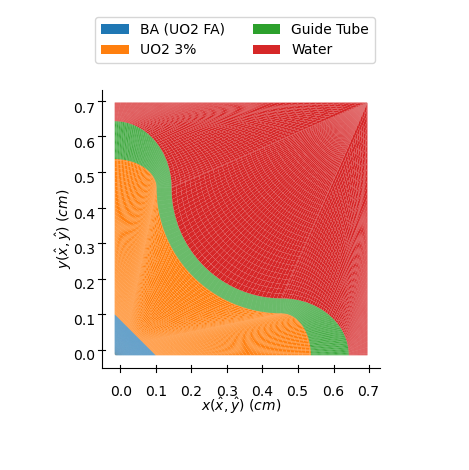

In [7]:
# Plot final mesh
ax = mesh.plot(num_nodes=128, plot_ctrlpts=False)
plt.legend(loc="upper center", ncol=2)
plt.tight_layout()
plt.savefig("./figs/four_lobe_ba.png", dpi=300)
plt.show()

In [8]:
print("Assemble system in COOrdinate format")
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
H_m, S_m, F_m, B_in_m, B_out_m = assembler.build()

# Create operators in TT format
print("\nAssemble system in TT format")
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
assembler.interp_jacobian = False
assembler.interp_jacobian_det = False
assembler.interp_boundary_jacobian_det = False
H_tt, S_tt, F_tt, B_in_tt, B_out_tt = assembler.build(use_tt=True, eps=1e-10)

# Save TT information
assembler.save_tt_info("./tt_info.csv")

Assemble system in COOrdinate format
Discretization: N = 1024, G = 7, P = 12, A = 7, B = 7
Assembling Patch 1
Step            Shape                     Compression  Elapsed Time (s)
H               4214784,4214784            982280.22        3.28
S               2,4116,4116                   279.78        3.29
F               4116,4116                     319.75        3.29
B_in            4214784,4214784           18990750.90        3.51
B_out           4214784,4214784           19189347.55        3.71
Assembling Patch 2
Step            Shape                     Compression  Elapsed Time (s)
H               4214784,4214784            982280.22        6.99
S               2,4116,4116                   279.78        6.99
F               4116,4116                     319.75        6.99
B_in            4214784,4214784           13774571.87        7.24
B_out           4214784,4214784           14066380.79        7.44
Assembling Patch 3
Step            Shape                     Compression 

In [9]:
k, psi = eig(
    LHS=LinearOperator([H_tt, B_out_m - B_in_m, -S_tt], N=assembler.N, M=assembler.M),
    RHS=LinearOperator([F_tt], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=1,
    linear_solver_opts={
        "max_iterations": 150,
        "threshold": 1e-10,
        "resets": 50,
    },
)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy().reshape(
    (xs_server.num_groups, mesh.num_patches, -1)
)

Starting power iteration
-- (0): k = 0.76586208, Angular Flux L2-Error = 3.46173385, Elapsed Time = 1064.176
-- (1): k = 0.83674488, Angular Flux L2-Error = 0.04864576, Elapsed Time = 2110.403
-- (2): k = 0.83899355, Angular Flux L2-Error = 0.00480701, Elapsed Time = 3154.777
-- (3): k = 0.83906489, Angular Flux L2-Error = 0.0020004, Elapsed Time = 4198.624
-- (4): k = 0.83906892, Angular Flux L2-Error = 0.00132201, Elapsed Time = 5244.502
-- (5): k = 0.83906954, Angular Flux L2-Error = 0.00093812, Elapsed Time = 6289.547
-- (6): k = 0.83907065, Angular Flux L2-Error = 0.0004894, Elapsed Time = 7335.878
-- (7): k = 0.83907111, Angular Flux L2-Error = 0.000241, Elapsed Time = 8379.743
-- (8): k = 0.83907132, Angular Flux L2-Error = 0.00011153, Elapsed Time = 9423.685
-- (9): k = 0.83907139, Angular Flux L2-Error = 4.684e-05, Elapsed Time = 10468.087
-- (10): k = 0.8390714, Angular Flux L2-Error = 2.112e-05, Elapsed Time = 11512.746
-- (11): k = 0.8390714, Angular Flux L2-Error = 1.139e-

In [4]:
# Get OpenMC solution
k_mc = [0.83940, 0.00005]
phi_mc = np.load("./openmc/lightbridge_openmc_absorber/data/mesh_flux.npy")

# Ensure OpenMC solution is normalized
phi_mc /= np.linalg.norm(phi_mc.flatten(), 2)

# Calculate eigenvalue error
print("keff error: {} +/- {} pcm".format((k - k_mc[0]) * 1e5, k_mc[1]))

NameError: name 'k' is not defined

In [6]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(2, 2))

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Calculate regular mesh
    phi_avg[g,] = mesh.regular_mesh(pids, coords)

    # Plot
    plt.clf()
    ax, cbar = mesh.plot(plot_ctrlpts=False)
    cbar.set_label(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_ba{g + 1}.png", dpi=300)
    plt.show()

# Normalize average
phi_avg /= np.linalg.norm(phi_avg.flatten(), 2)

for g in range(xs_server.num_groups):
    # Calculate groups L2-error
    print(
        "Scalar flux Relative L2-error (g = {}): {}".format(
            g + 1, 
            np.linalg.norm(
                (phi_avg[g,] - phi_mc[g,]).flatten(), 2
            ) / np.linalg.norm(phi_mc[g,].flatten(), 2)
        )
    )
print(
    "Total scalar flux Relative L2-error: {}".format(
        np.linalg.norm(
            (phi_avg - phi_mc).flatten(), 2
        ) / np.linalg.norm(phi_mc.flatten(), 2)
    )
)

NameError: name 'mesh' is not defined